<a href="https://colab.research.google.com/github/DemetrisPitsillides/MAI623_DSC514_-No-Link-Provided-_Spring_2026/blob/main/Task%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All installations
!pip install lxml_html_clean
!pip install trafilatura newspaper3k
!pip install langchain
!pip install docling
!pip install pandas matplotlib scikit-learn -q
!pip install textblob -q
!pip install transformers torch scikit-learn pandas -q
!pip install -U "transformers==4.49.0" "huggingface_hub==0.29.3" "tokenizers==0.21.0"

  Using cached transformers-4.49.0-py3-none-any.whl.metadata (44 kB)
  Using cached huggingface_hub-0.29.3-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.21.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.49.0-py3-none-any.whl (10.0 MB)
Using cached huggingface_hub-0.29.3-py3-none-any.whl (468 kB)
Using cached tokenizers-0.21.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.4
    Uninstalling tokenizers-0.21.4:
      Successfully uninstalled tokenizers-0.21.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.4
    Uninstalling transformers-4.55.4:
      Successfully uninstalled transformer

In [ ]:
#All imports
import pandas as pd
import numpy as np
import os
import requests
from newspaper import Article
from urllib.parse import urlparse
import trafilatura
import re
import glob
import math
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/Margot FuldeHardy_FIMI_Elections_Dataset_vF_07_01.csv", header=1)

In [ ]:
df.shape

(81, 154)

In [ ]:
df.head()

,Year,Target Country,Event,Region,Sub-region,Country of Origin,Threat Actor,Event description,T0002_Facilitate State Propaganda,T0072_Segment Audiences,...,Attribution Source: Company,Attribution Source: Researchers/Journalists,Source 1,Source 2,Source 3,Source 4,Source 5,Source 6,Source 7,Source 8
0,2014,Scotland,Referendum,Europe,Western Europe,Russia*,IRA*,Referendum on the independence of Scotland,0,0,...,0,0,https://medium.com/dfrlab/electionwatch-scotti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,Scotland,Referendum,Europe,Western Europe,Iran,IRIB,Referendum on the independence of Scotland,1,0,...,1,0,https://www.heraldscotland.com/news/16592877.f...,https://www.mandiant.com/resources/blog/suspec...,https://www.washingtonpost.com/news/democracy-...,Taking Down More Coordinated Inauthentic Behav...,https://public-assets.graphika.com/reports/gra...,NaN,NaN,NaN
2,2014,Ukraine,Presidential Election,Europe,Eastern Europe,Russia,GRU,Ukraine Presidential Election,1,0,...,0,1,https://www.washingtonpost.com/world/national-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,Bosnia-Herzegovina,Local Election,Europe,Southern Europe,Russia,Malofeev,Local Election Bosnia-Herzegovina,1,0,...,0,1,https://www.bellingcat.com/news/uk-and-europe/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,Canada,General Election,Americas,North America,Russia,Unknown,Canada Federal Election,0,0,...,0,0,https://www.researchgate.net/publication/34927...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isna()

,Year,Target Country,Event,Region,Sub-region,Country of Origin,Threat Actor,Event description,T0002_Facilitate State Propaganda,T0072_Segment Audiences,...,Attribution Source: Company,Attribution Source: Researchers/Journalists,Source 1,Source 2,Source 3,Source 4,Source 5,Source 6,Source 7,Source 8
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
77,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
78,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
79,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True


In [ ]:
print(df.isnull().sum())

Year               0
Target Country     0
Event              0
Region             0
Sub-region         0
                  ..
Source 4          46
Source 5          54
Source 6          63
Source 7          72
Source 8          74
Length: 154, dtype: int64


In [ ]:
df=df.dropna(axis=1, how='all')
df.shape

(81, 154)

In [ ]:
#Get all column names that start with 'Source'
source_columns = [col for col in df.columns if col.startswith('Source')]

for col in source_columns:
    # Replace values that do not start with 'https' with NaN in each source column
    df[col] = np.where(df[col].astype(str).str.startswith('https','http'), df[col], np.nan)

display(df.head())

,Year,Target Country,Event,Region,Sub-region,Country of Origin,Threat Actor,Event description,T0002_Facilitate State Propaganda,T0072_Segment Audiences,...,Attribution Source: Company,Attribution Source: Researchers/Journalists,Source 1,Source 2,Source 3,Source 4,Source 5,Source 6,Source 7,Source 8
0,2014,Scotland,Referendum,Europe,Western Europe,Russia*,IRA*,Referendum on the independence of Scotland,0,0,...,0,0,https://medium.com/dfrlab/electionwatch-scotti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,Scotland,Referendum,Europe,Western Europe,Iran,IRIB,Referendum on the independence of Scotland,1,0,...,1,0,https://www.heraldscotland.com/news/16592877.f...,https://www.mandiant.com/resources/blog/suspec...,https://www.washingtonpost.com/news/democracy-...,NaN,https://public-assets.graphika.com/reports/gra...,NaN,NaN,NaN
2,2014,Ukraine,Presidential Election,Europe,Eastern Europe,Russia,GRU,Ukraine Presidential Election,1,0,...,0,1,https://www.washingtonpost.com/world/national-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,Bosnia-Herzegovina,Local Election,Europe,Southern Europe,Russia,Malofeev,Local Election Bosnia-Herzegovina,1,0,...,0,1,https://www.bellingcat.com/news/uk-and-europe/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,Canada,General Election,Americas,North America,Russia,Unknown,Canada Federal Election,0,0,...,0,0,https://www.researchgate.net/publication/34927...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Identify source columns
source_cols = [col for col in df.columns if col.startswith("Source")]

# Add incident ID column (if none exists)
df["incident_id"] = df.index.astype(str)

# Reshape dataset to long format
long_df = df.melt(
    id_vars=["incident_id"],
    value_vars=source_cols,
    var_name="source_number",
    value_name="url"
)

# Drop empty URLs
long_df = long_df.dropna(subset=["url"])

# Create folders
os.makedirs("data/raw_html", exist_ok=True)
os.makedirs("data/raw_pdf", exist_ok=True)


In [ ]:
print("Total incidents:", df.shape[0])
print("Total article URLs:", long_df.shape[0])

Total incidents: 81
Total article URLs: 266


In [ ]:
long_df["url"].str.endswith(".pdf", na=False).sum()

np.int64(53)

In [ ]:
long_df[long_df["url"].str.startswith("https", na=False) & ~long_df["url"].str.endswith(".pdf", na=False)]

,incident_id,source_number,url
0,0,Source 1,https://medium.com/dfrlab/electionwatch-scotti...
1,1,Source 1,https://www.heraldscotland.com/news/16592877.f...
2,2,Source 1,https://www.washingtonpost.com/world/national-...
3,3,Source 1,https://www.bellingcat.com/news/uk-and-europe/...
4,4,Source 1,https://www.researchgate.net/publication/34927...
...,...,...,...
584,17,Source 8,https://www.realinstitutoelcano.org/en/analyse...
588,21,Source 8,https://www.dw.com/en/kenyans-debate-cambridge...
619,52,Source 8,https://www.reuters.com/article/usa-election-r...
629,62,Source 8,https://medium.com/dfrlab/election-fraud-narra...


In [ ]:
#Create Output Folders
os.makedirs("data/raw_html", exist_ok=True)
os.makedirs("data/raw_pdf", exist_ok=True)

#Store failed urls
failed_urls = []

for _, row in long_df.iterrows(): #Loop through the dataframe
    incident_id = row["incident_id"]
    source_number = row["source_number"].replace(" ", "_") #Replace spaces with _ (Source 1 becomes Source_1)
    url = row["url"]

    filename_base = f"{incident_id}_{source_number}" #Create the filename

    try:
        if url.lower().endswith(".pdf"): #If it ends with .pdf, we treat it as a pdf file
            response = requests.get(url, timeout=15) #Waits 15 seconds and raises error if the status code is e.g.404
            response.raise_for_status()

            filepath = f"data/raw_pdf/{filename_base}.pdf"
            with open(filepath, "wb") as f:
                f.write(response.content)

        else: #If not pdf
            # First try newspaper, as it's used to extract news articles by identifying main article text, authors etc.
            try:
                article = Article(url)
                article.download()
                article.parse()
                text = article.text
            except:
                text = None

            # If newspaper fails, try trafilatura, which is a robust web text extraction library that removes ads,menus etc.
            if not text:
                downloaded = trafilatura.fetch_url(url)
                text = trafilatura.extract(downloaded)

            if text:
                filepath = f"data/raw_html/{filename_base}.txt"
                with open(filepath, "w", encoding="utf-8") as f:
                    f.write(text)
                print(f"Downloaded: {filename_base}")
            else:
                raise Exception("No text extracted")

    except Exception as e: #If extraction fails, continue and count it as failed url instead of stopping
        print(f"Failed: {url}")
        failed_urls.append(url)

print("\nDone.")
print("Failed URLs:", len(failed_urls))

ERROR:trafilatura.downloads:not a 200 response: 403 for URL https://medium.com/dfrlab/electionwatch-scottish-vote-pro-kremlin-trolls-f3cca45045bb


Failed: https://medium.com/dfrlab/electionwatch-scottish-vote-pro-kremlin-trolls-f3cca45045bb
Downloaded: 1_Source_1
Downloaded: 2_Source_1
Downloaded: 3_Source_1


ERROR:trafilatura.downloads:not a 200 response: 403 for URL https://www.researchgate.net/publication/349278205_How_did_Russian_and_Iranian_trolls%27_disinformation_toward_Canadian_issues_diverge_and_converge
ERROR:trafilatura.downloads:not a 200 response: 403 for URL https://www.researchgate.net/publication/349278205_How_did_Russian_and_Iranian_trolls%27_disinformation_toward_Canadian_issues_diverge_and_converge


Failed: https://www.researchgate.net/publication/349278205_How_did_Russian_and_Iranian_trolls%27_disinformation_toward_Canadian_issues_diverge_and_converge
Failed: https://www.researchgate.net/publication/349278205_How_did_Russian_and_Iranian_trolls%27_disinformation_toward_Canadian_issues_diverge_and_converge
Downloaded: 6_Source_1
Downloaded: 7_Source_1
Downloaded: 9_Source_1
Downloaded: 10_Source_1
Downloaded: 11_Source_1
Downloaded: 12_Source_1


Failed: https://time.com/4955503/germany-elections-2017-far-right-russia-angela-merkel/


...

Downloaded: 9_Source_8
Failed: https://ushadrons.medium.com/
Downloaded: 17_Source_8


ERROR:trafilatura.downloads:not a 200 response: 401 for URL https://www.reuters.com/article/usa-election-russia-disinformation/exclusive-russian-operation-masqueraded-as-right-wing-news-site-to-target-u-s-voters-sources-idUSKBN26M5OP/


Downloaded: 21_Source_8
Failed: https://www.reuters.com/article/usa-election-russia-disinformation/exclusive-russian-operation-masqueraded-as-right-wing-news-site-to-target-u-s-voters-sources-idUSKBN26M5OP/


ERROR:trafilatura.downloads:not a 200 response: 403 for URL https://medium.com/dfrlab/election-fraud-narratives-surge-on-brazilian-twitter-following-bolsonaro-defeat-e1876a45a137


Failed: https://medium.com/dfrlab/election-fraud-narratives-surge-on-brazilian-twitter-following-bolsonaro-defeat-e1876a45a137
Downloaded: 67_Source_8

Done.
Failed URLs: 77


In [ ]:
print("Total source rows:", len(long_df))
print("Failed attempts:", len(failed_urls))
print("Successful downloads:", len(long_df) - len(failed_urls))

Total source rows: 266
Failed attempts: 77
Successful downloads: 189


In [ ]:
failed_df = pd.DataFrame({"failed_url": failed_urls})
failed_df.to_csv("failed_urls.csv", index=False)

In [ ]:
#Create folders if they don't exist
os.makedirs("data/manual_html", exist_ok=True)
os.makedirs("data/manual_pdf", exist_ok=True)

In [ ]:
failed_links_df = long_df[long_df["url"].isin(failed_urls)][["incident_id", "source_number", "url"]]
failed_links_df

,incident_id,source_number,url
0,0,Source 1,https://medium.com/dfrlab/electionwatch-scotti...
4,4,Source 1,https://www.researchgate.net/publication/34927...
5,5,Source 1,https://www.researchgate.net/publication/34927...
13,13,Source 1,https://time.com/4955503/germany-elections-201...
15,15,Source 1,https://medium.com/dfrlab/far-right-targets-ge...
...,...,...,...
445,40,Source 6,https://www.isdglobal.org/isd-publications/dis...
503,17,Source 7,https://euvsdisinfo.eu/russian-tvs-view-on-cat...
579,12,Source 8,https://ushadrons.medium.com/
619,52,Source 8,https://www.reuters.com/article/usa-election-r...


In [ ]:
#Task 2
#Paths
BASE_PATH = "/content/drive/MyDrive/NLP"
ARTICLES_PATH = os.path.join(BASE_PATH, "articles")
DATA_PATH = os.path.join(BASE_PATH, "data")
RAW_HTML_PATH = os.path.join(DATA_PATH, "raw_html")
HTML_PARSED_MD_PATH = os.path.join(DATA_PATH, "html_parsed_markdown")
MANUAL_HTML_PATH = os.path.join(DATA_PATH, "manual_html")
MANUAL_HTML_PARSED_MD_PATH = os.path.join(DATA_PATH, "manual_html_parsed_markdown")
RAW_PDF_PATH = os.path.join(DATA_PATH, "raw_pdf")
PDF_PARSED_MD_PATH = os.path.join(DATA_PATH, "pdf_parsed_markdown")
FAILED_URLS_PATH = os.path.join(BASE_PATH, "failed_urls.csv")
FAILED_LINKS_PATH = os.path.join(BASE_PATH, "failed_links_df.csv")

In [1]:
#Task 2
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DATASET_PATH = "/content/Margot FuldeHardy_FIMI_Elections_Dataset_vF_07_01.csv"
df = pd.read_csv(DATASET_PATH, header=1)
df["incident_id"] = df.index.astype(str)
print("Shape:", df.shape)
print(df.head(2))
print(df.columns.tolist())

Shape: (81, 155)
   Year Target Country       Event   Region      Sub-region Country of Origin  \
0  2014       Scotland  Referendum  Europe   Western Europe           Russia*   
1  2014       Scotland  Referendum  Europe   Western Europe              Iran   

  Threat Actor                           Event description  \
0         IRA*  Referendum on the independence of Scotland   
1         IRIB  Referendum on the independence of Scotland   

   T0002_Facilitate State Propaganda  T0072_Segment Audiences  ...  \
0                                  0                        0  ...   
1                                  1                        0  ...   

   Attribution Source: Researchers/Journalists  \
0                                            0   
1                                            0   

                                            Source 1  \
0  https://medium.com/dfrlab/electionwatch-scotti...   
1  https://www.heraldscotland.com/news/16592877.f...   

                     

In [3]:
#Detect Important Column Groups
SOURCE_COLS = [col for col in df.columns if str(col).startswith("Source")]

TECHNIQUE_COLS = [
    col for col in df.columns
    if re.match(r"^T\d{4}", str(col).strip())
]

print("Number of source columns:", len(SOURCE_COLS))
print("Source columns:", SOURCE_COLS)

print("Number of technique columns:", len(TECHNIQUE_COLS))
print("First 20 technique columns:", TECHNIQUE_COLS[:20])

Number of source columns: 8
Source columns: ['Source 1', 'Source 2', 'Source 3', 'Source 4', 'Source 5', 'Source 6', 'Source 7', 'Source 8']
Number of technique columns: 107
First 20 technique columns: ['T0002_Facilitate State Propaganda', 'T0072_Segment Audiences', 'T0072.001_Geographic Segmentation', 'T0072.002_Demographic Segmentation', 'T0072.005_Political Segmentation', 'T0081.007_Identify Target Audience Adversaries', 'T0003_Leverage Existing Narratives', 'T0004_ Develop Competing Narratives', 'T0022_Leverage Conspiracy Theory Narratives', 'T0022.001_ Amplify Existing Conspiracy Theory  Narratives', 'T0068_Respond to Breaking News Event or Active Crisis', 'T0082_Develop New Narratives', 'T0083_Integrate Target Audience Vulnerabilities into Narrative', 'T0023_Distort Facts', 'T0023.001_Reframe Context', 'T0084.001_Use Copy Pasta', 'T0084.002_Plagiarise Content', 'T0084.003_Deceptively Labelled or Translated', 'T0084.004_Appropriate Content', 'T0085_Develop Text-Based Content']


In [5]:
#Find Column By Keyword
def find_col(possible_keywords, columns):
    for kw in possible_keywords:
        for col in columns:
            if kw.lower() in str(col).lower():
                return col
    return None

region_col = find_col(["region"], df.columns)
target_country_col = find_col(["target country"], df.columns)
origin_country_col = find_col(["country of origin", "origin country"], df.columns)
year_col = find_col(["year"], df.columns)

print("region_col:", region_col)
print("target_country_col:", target_country_col)
print("origin_country_col:", origin_country_col)
print("year_col:", year_col)

region_col: Region
target_country_col: Target Country
origin_country_col: Country of Origin
year_col: Year


In [6]:
#Year Extraction
date_col = find_col(["date"], df.columns)

if year_col is None and date_col is not None:
    df["derived_year"] = pd.to_datetime(df[date_col], errors="coerce").dt.year
    year_col = "derived_year"

print("Using year column:", year_col)
if year_col:
    print(df[year_col].value_counts(dropna=False).sort_index())

Using year column: Year
Year
2014     4
2015     5
2016     4
2017    12
2018    13
2019    10
2020    11
2021     2
2022     9
2023     2
2024     9
Name: count, dtype: int64


Year
2014     4
2015     5
2016     4
2017    12
2018    13
2019    10
2020    11
2021     2
2022     9
2023     2
2024     9
Name: count, dtype: int64


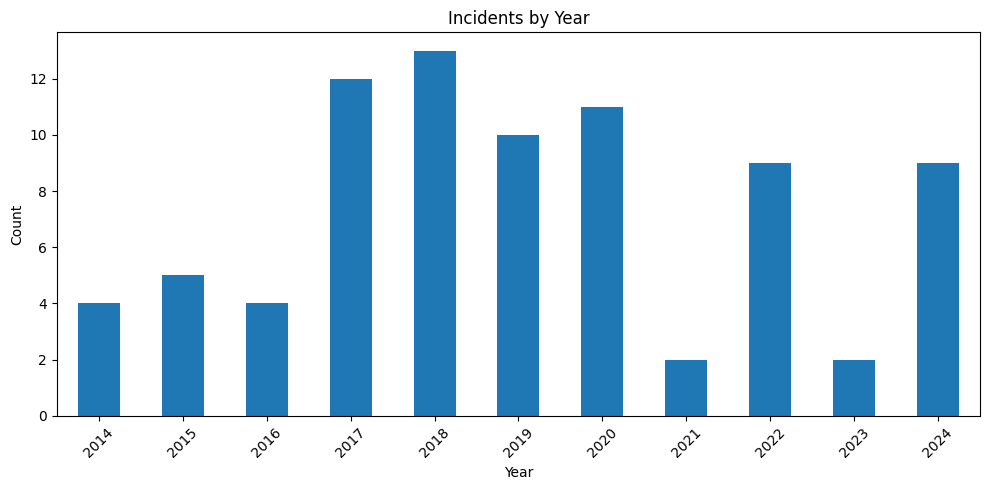

In [7]:
#Distribution By Year
if year_col:
    year_counts = (df[year_col].dropna().astype(int).value_counts().sort_index())
    print(year_counts)
    plt.figure(figsize=(10, 5))
    year_counts.plot(kind="bar")
    plt.title("Incidents by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No year column found.")

Region
Europe          29
Americas        27
Africa          12
Asia-Oceania     9
Africa           3
Middle-East      1
Name: count, dtype: int64


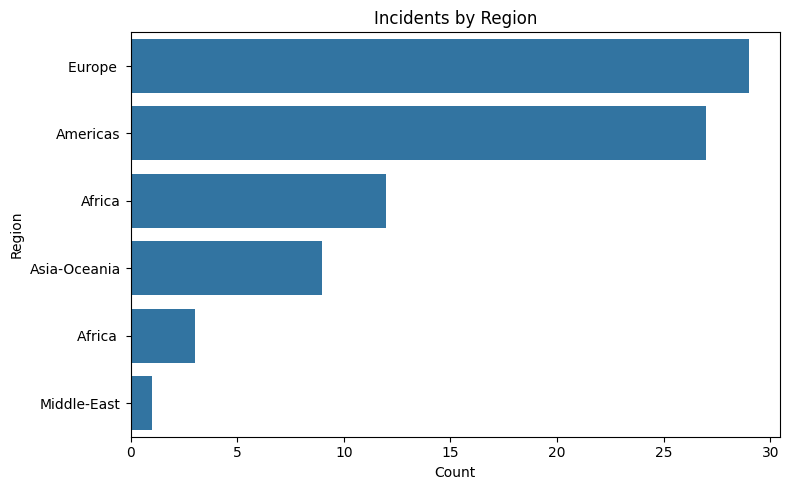

In [8]:
#Distribution By Region
if region_col:
    region_counts = df[region_col].fillna("Unknown").value_counts()
    print(region_counts)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=region_counts.values, y=region_counts.index)
    plt.title("Incidents by Region")
    plt.xlabel("Count")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()
else:
    print("No region column found.")

Target Country
United-States      15
Germany             5
France              4
Taiwan              4
United-Kingdom      3
Canada              3
Scotland            2
Nigeria             2
Venezuela           2
Brazil              2
Sweden              2
Ukraine             2
Togo                2
Solomon Islands     2
Tunisia             2
Name: count, dtype: int64


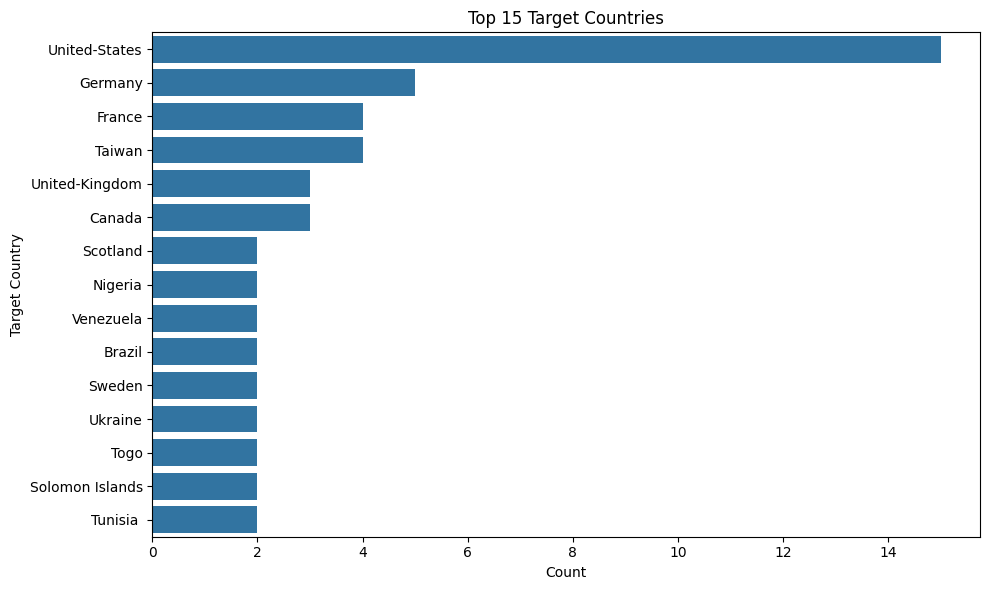

In [9]:
#Most Targeted Countries
if target_country_col:
    target_country_counts = (
        df[target_country_col]
        .fillna("Unknown")
        .value_counts()
        .head(15)
    )
    print(target_country_counts)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=target_country_counts.values, y=target_country_counts.index)
    plt.title("Top 15 Target Countries")
    plt.xlabel("Count")
    plt.ylabel("Target Country")
    plt.tight_layout()
    plt.show()
else:
    print("No target country column found.")

Country of Origin
Russia                                    25
China                                     12
Iran                                       7
Russia                                     6
United-States                              6
Israel                                     5
Ecuador/Canada                             4
Tunisia                                    4
Russia*                                    3
United-Kingdom                             2
Turkey                                     1
Venezuela                                  1
China*                                     1
Vietnam and Thailand and United-States     1
United-States and Venezuela                1
Name: count, dtype: int64


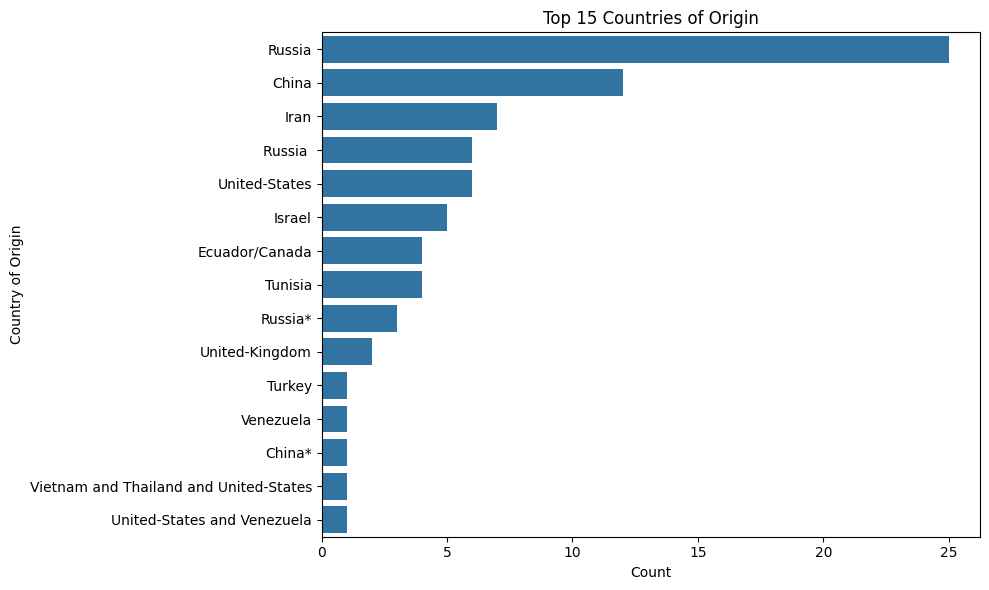

In [10]:
#Most Common Countries of Origin
if origin_country_col:
    origin_country_counts = (
        df[origin_country_col]
        .fillna("Unknown")
        .value_counts()
        .head(15)
    )

    print(origin_country_counts)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=origin_country_counts.values, y=origin_country_counts.index)
    plt.title("Top 15 Countries of Origin")
    plt.xlabel("Count")
    plt.ylabel("Country of Origin")
    plt.tight_layout()
    plt.show()
else:
    print("No country of origin column found.")

In [11]:
#Technique Frequencies
def technique_is_present(x):
    if pd.isna(x):
        return 0
    x = str(x).strip().lower()
    return 0 if x in ["", "0", "false", "nan", "none"] else 1
technique_presence = df[TECHNIQUE_COLS].applymap(technique_is_present)
technique_counts = technique_presence.sum().sort_values(ascending=False)
print(technique_counts.head(20))

T0096.001_Create Content Farms                                    80
T0104.001_Mainstream Social Networks                              69
T0115_Post Content                                                59
T0090_Create Inauthentic Accounts                                 40
T0007_Create Inauthentic Social Media Pages and Groups            37
T0068_Respond to Breaking News Event or Active Crisis             34
T0003_Leverage Existing Narratives                                33
T0082_Develop New Narratives                                      31
T0099_Impersonate Existing Entities                               30
T0087_Develop Video-Based Content                                 30
T0097_Create Personas                                             28
T0018_Purchase Targeted Advertisements                            26
T0122_Direct Users to Alternative Platforms                       26
T0114_Deliver Ads                                                 24
T0083_Integrate Target Audience Vu

/tmp/ipykernel_19654/2227604067.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  technique_presence = df[TECHNIQUE_COLS].applymap(technique_is_present)


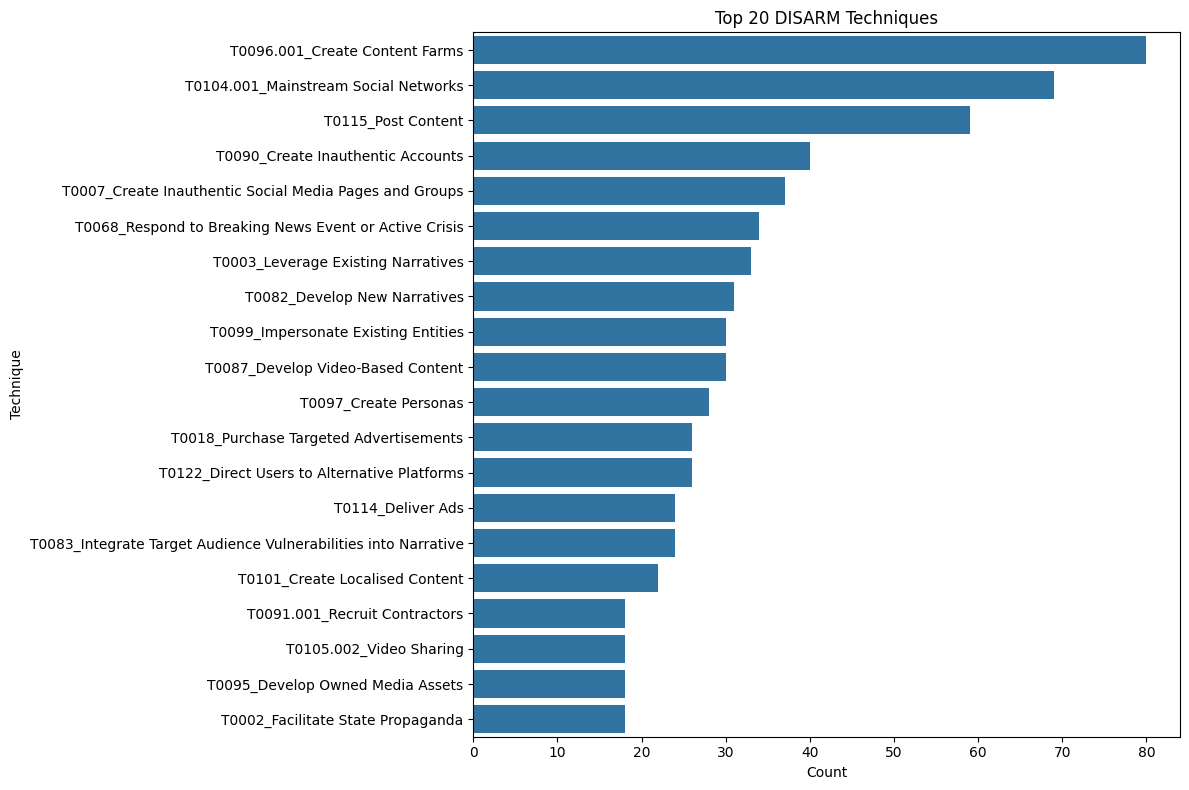

In [12]:
#Top Frequencies Bar Chart
top_n = 20
top_techniques = technique_counts.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_techniques.values, y=top_techniques.index)
plt.title(f"Top {top_n} DISARM Techniques")
plt.xlabel("Count")
plt.ylabel("Technique")
plt.tight_layout()
plt.show()

count    81.000000
mean     14.419753
std       7.104337
min       4.000000
25%      10.000000
50%      13.000000
75%      17.000000
max      44.000000
Name: num_techniques, dtype: float64


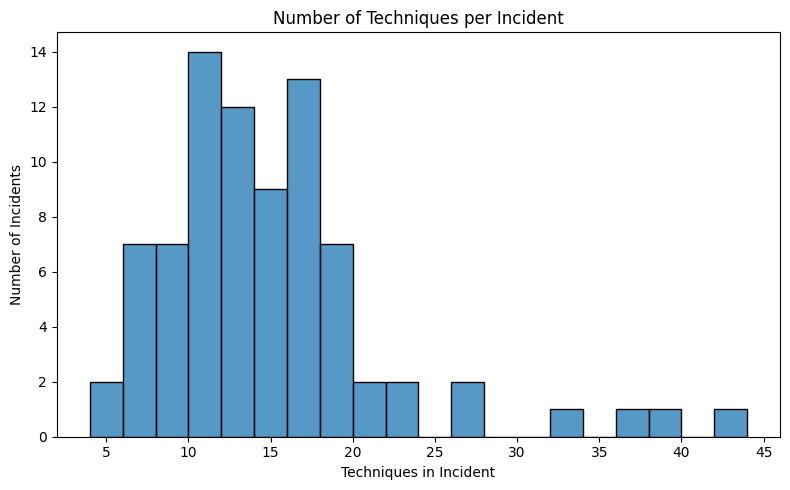

In [13]:
#Number of Techniques per Incident
df["num_techniques"] = technique_presence.sum(axis=1)
print(df["num_techniques"].describe())
plt.figure(figsize=(8, 5))
sns.histplot(df["num_techniques"], bins=20, kde=False)
plt.title("Number of Techniques per Incident")
plt.xlabel("Techniques in Incident")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

In [ ]:
#Helper Functions
def list_files(folder_path):
    if not os.path.exists(folder_path):
        return []
    return [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

def read_text_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    except:
        return ""

def count_words(text):
    return len(re.findall(r"\b\w+\b", text))

def count_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

def clean_for_freq(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

STOPWORDS = {
    "the","and","is","in","to","of","for","on","that","with","as","are","was","by",
    "it","from","at","an","be","this","which","or","we","can","has","have","had", "some", "what",
    "will","not","their","its","but","they","a","our","may","also","more","than", "his", "were", "these", "about", "been", "who"
}


def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        cleaned = clean_for_freq(text)
        words = [w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

In [ ]:
#Data Collection
#Count files in each folder
folder_counts = {
    "articles": len(list_files(ARTICLES_PATH)),
    "raw_html": len(list_files(RAW_HTML_PATH)),
    "html_parsed_markdown": len(list_files(HTML_PARSED_MD_PATH)),
    "manual_html": len(list_files(MANUAL_HTML_PATH)),
    "manual_html_parsed_markdown": len(list_files(MANUAL_HTML_PARSED_MD_PATH)),
    "raw_pdf": len(list_files(RAW_PDF_PATH)),
    "pdf_parsed_markdown": len(list_files(PDF_PARSED_MD_PATH)),
}

folder_counts_df = pd.DataFrame(
    {"folder": list(folder_counts.keys()), "file_count": list(folder_counts.values())}
)

folder_counts_df

,folder,file_count
0,articles,59
1,raw_html,136
2,html_parsed_markdown,136
3,manual_html,0
4,manual_html_parsed_markdown,59
5,raw_pdf,58
6,pdf_parsed_markdown,94


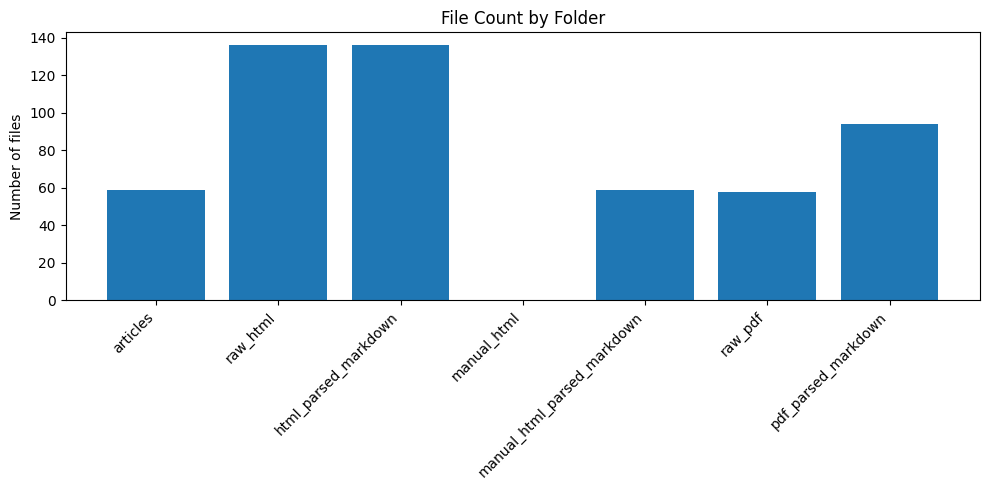

In [ ]:
#Plot files per folder
plt.figure(figsize=(10, 5))
plt.bar(folder_counts_df["folder"], folder_counts_df["file_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of files")
plt.title("File Count by Folder")
plt.tight_layout()
plt.show()

In [ ]:
#Failed Files overview
failed_total = 0

if os.path.exists(FAILED_URLS_PATH):
    failed_df = pd.read_csv(FAILED_URLS_PATH)
    failed_total = len(failed_df)
    print("Unique failed URLs:", failed_total)

elif os.path.exists(FAILED_LINKS_PATH):
    failed_df = pd.read_csv(FAILED_LINKS_PATH)
    failed_total = len(failed_df)
    print("Failed links:", failed_total)

else:
    print("No failure file found")

Unique failed URLs: 77


In [ ]:
successful_files = folder_counts.get("articles", 0)

Total attempts: 266
Successful downloads: 189
Failed attempts: 77


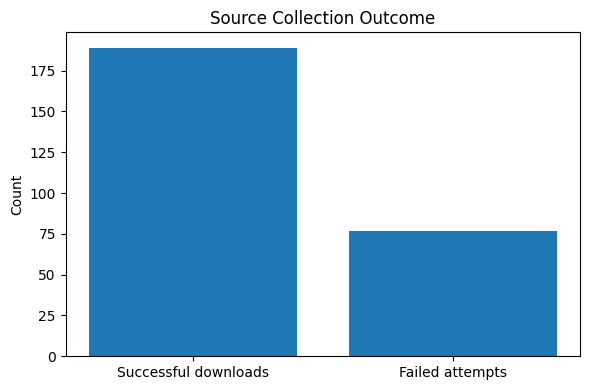

In [ ]:
#Success vs failed collection chart initially
attempted = len(long_df)
failed = len(failed_urls)

successful = attempted - failed

print("Total attempts:", attempted)
print("Successful downloads:", successful)
print("Failed attempts:", failed)

plt.figure(figsize=(6,4))
plt.bar(["Successful downloads", "Failed attempts"], [successful, failed])
plt.ylabel("Count")
plt.title("Source Collection Outcome")
plt.tight_layout()
plt.show()

Total attempts: 266
Automated successes: 189
Initial failed attempts: 77
Manual recovered files: 59
Estimated final successes: 248
Estimated remaining failures: 18


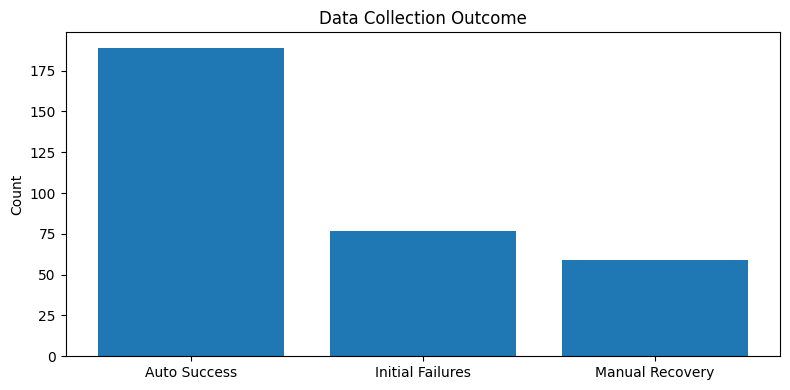

In [ ]:
BASE_PATH = "/content/drive/MyDrive/NLP/data"
RAW_HTML_PATH = os.path.join(BASE_PATH, "raw_html")
RAW_PDF_PATH = os.path.join(BASE_PATH, "raw_pdf")
MANUAL_PATH = os.path.join(BASE_PATH, "manual_html_parsed_markdown")
#Counts
attempted = len(long_df)
initial_failed = len(failed_urls)
auto_success = attempted - initial_failed

manual_recovered = len([
    f for f in os.listdir(MANUAL_PATH)
    if os.path.isfile(os.path.join(MANUAL_PATH, f))
]) if os.path.exists(MANUAL_PATH) else 0

estimated_final_success = auto_success + manual_recovered


estimated_remaining_failures = max(initial_failed - manual_recovered, 0)

#Summary
print("Total attempts:", attempted)
print("Automated successes:", auto_success)
print("Initial failed attempts:", initial_failed)
print("Manual recovered files:", manual_recovered)
print("Estimated final successes:", estimated_final_success)
print("Estimated remaining failures:", estimated_remaining_failures)

#Chart
plt.figure(figsize=(8,4))
plt.bar(
    ["Auto Success", "Initial Failures", "Manual Recovery"],
    [auto_success, initial_failed, manual_recovered]
)
plt.ylabel("Count")
plt.title("Data Collection Outcome")
plt.tight_layout()
plt.show()

In [ ]:
#Part 2: Text EDA

#Load Text Data
rows = []

for fname in list_files(HTML_PARSED_MD_PATH):
    fpath = os.path.join(HTML_PARSED_MD_PATH, fname)
    text = read_text_file(fpath)

    rows.append({
        "file_name": fname,
        "text": text,
        "char_count": len(text),
        "word_count": count_words(text),
        "sentence_count": count_sentences(text)
    })

text_df = pd.DataFrame(rows)

print("Documents loaded:", len(text_df))
text_df.head()

Documents loaded: 136


,file_name,text,char_count,word_count,sentence_count
0,29_Source_2.md,"Today we removed multiple Pages, Groups and ac...",4771,795,41
1,68_Source_4.md,簡介\n媒體\n著作權\n與我們聯絡\n創作者\n廣告\n開發人員\n條款\n隱私權\n政策...,78,16,1
2,69_Source_1.md,": Vidéo Réseaux Poutine : ""Complément d'enquêt...",3163,511,23
3,9_Source_8.md,"64.\n\n(1) PBS and France24 shared content, da...",1696,296,12
4,19_Source_3.md,Two days before France's recent presidential e...,4672,756,30


In [ ]:
text_df[["char_count", "word_count", "sentence_count"]].describe()

,char_count,word_count,sentence_count
count,136.000000,136.000000,136.000000
mean,7070.801471,1127.507353,51.360294
std,6656.243030,1062.164220,50.073823
min,7.000000,2.000000,1.000000
25%,3476.750000,530.000000,21.000000
50%,5139.500000,800.500000,34.000000
75%,8530.500000,1390.500000,65.750000
max,41455.000000,6336.000000,302.000000


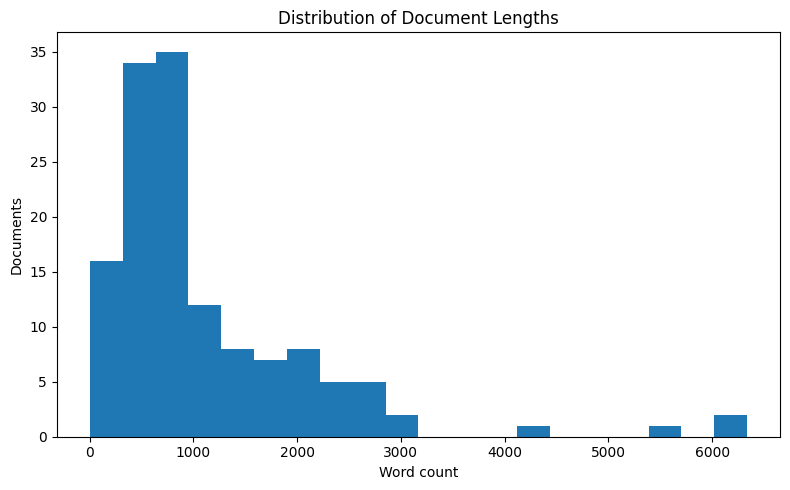

In [ ]:
#Histogram of Document lengths
plt.figure(figsize=(8,5))
plt.hist(text_df["word_count"], bins=20)
plt.xlabel("Word count")
plt.ylabel("Documents")
plt.title("Distribution of Document Lengths")
plt.tight_layout()
plt.show()

In [ ]:
#Empty/Very short files
empty_docs = (text_df["word_count"] == 0).sum()
short_docs = (text_df["word_count"] < 20).sum()

print("Empty documents:", empty_docs)
print("Documents under 20 words:", short_docs)

Empty documents: 0
Documents under 20 words: 5


In [ ]:
#Sources per incident
# Extract incident id from filename
text_df["incident_id"] = text_df["file_name"].str.extract(r"^(\d+)_").astype(int)

# Count sources per incident
incident_counts = text_df.groupby("incident_id").size().reset_index(name="source_count")

incident_counts.head()

,incident_id,source_count
0,1,3
1,2,1
2,3,1
3,6,1
4,7,4


In [ ]:
#Table
source_distribution = (incident_counts["source_count"].value_counts().sort_index().reset_index())
source_distribution.columns = ["num_sources", "num_incidents"]
source_distribution

,num_sources,num_incidents
0,1,29
1,2,18
2,3,6
3,4,4
4,5,2
5,6,2
6,7,1
7,8,1


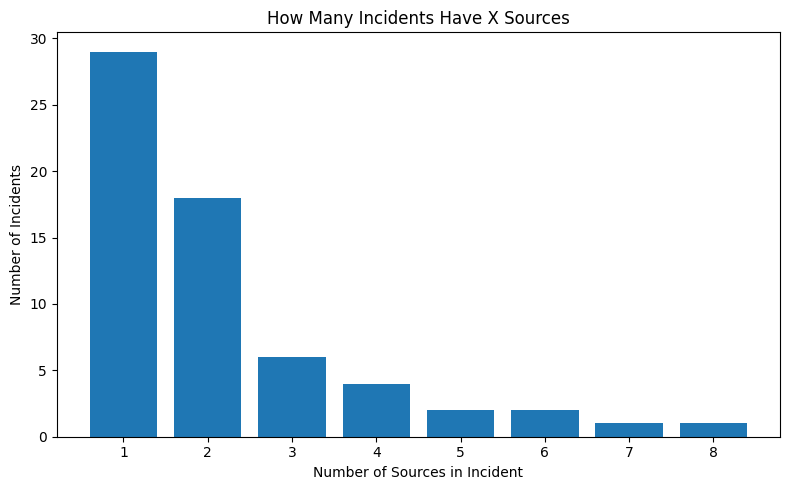

In [ ]:
#Graph
plt.figure(figsize=(8,5))
plt.bar(source_distribution["num_sources"].astype(str), source_distribution["num_incidents"])
plt.xlabel("Number of Sources in Incident")
plt.ylabel("Number of Incidents")
plt.title("How Many Incidents Have X Sources")
plt.tight_layout()
plt.show()

In [ ]:
#Top Unigrams
from collections import Counter

all_words = []

for text in text_df["text"]:
    cleaned = clean_for_freq(text)
    words = [
        w for w in cleaned.split()
        if w not in STOPWORDS and len(w) > 2
    ]
    all_words.extend(words)

unigrams = Counter(all_words).most_common(20)

uni_df = pd.DataFrame(unigrams, columns=["word", "freq"])
uni_df

,word,freq
0,accounts,817
1,russian,588
2,one,474
3,election,471
4,media,469
5,facebook,456
6,said,397
7,people,380
8,political,368
9,pages,348


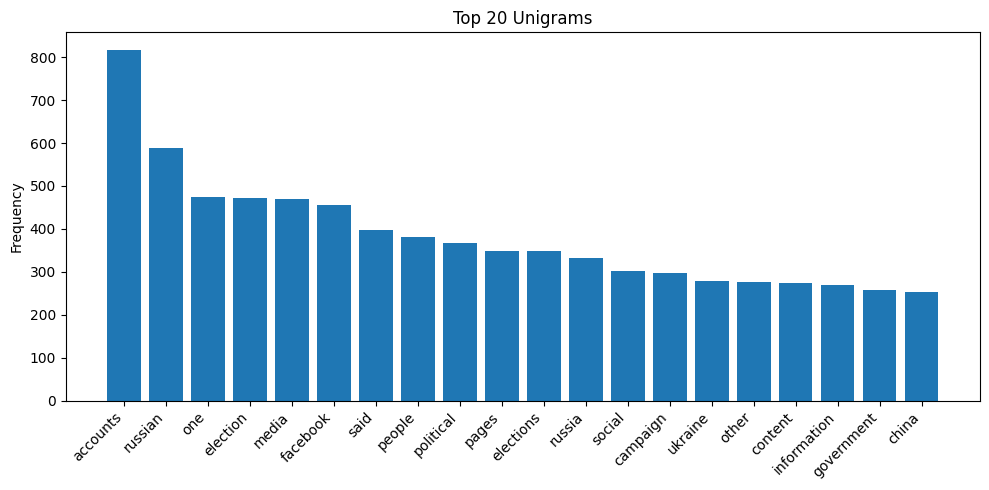

In [ ]:
#Graph
plt.figure(figsize=(10,5))
plt.bar(uni_df["word"], uni_df["freq"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Top 20 Unigrams")
plt.tight_layout()
plt.show()

In [ ]:
#Top Bigrams
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(text_df["text"])

bigram_counts = np.array(X.sum(axis=0)).flatten()
bigram_terms = vectorizer.get_feature_names_out()

bi_df = pd.DataFrame({
    "bigram": bigram_terms,
    "freq": bigram_counts
}).sort_values("freq", ascending=False)

bi_df

,bigram,freq
16,social media,223
3,cambridge analytica,159
12,instagram accounts,120
8,followed one,106
19,united states,90
10,inauthentic behavior,89
4,coordinated inauthentic,89
5,facebook accounts,84
9,he said,76
1,accounts followed,72


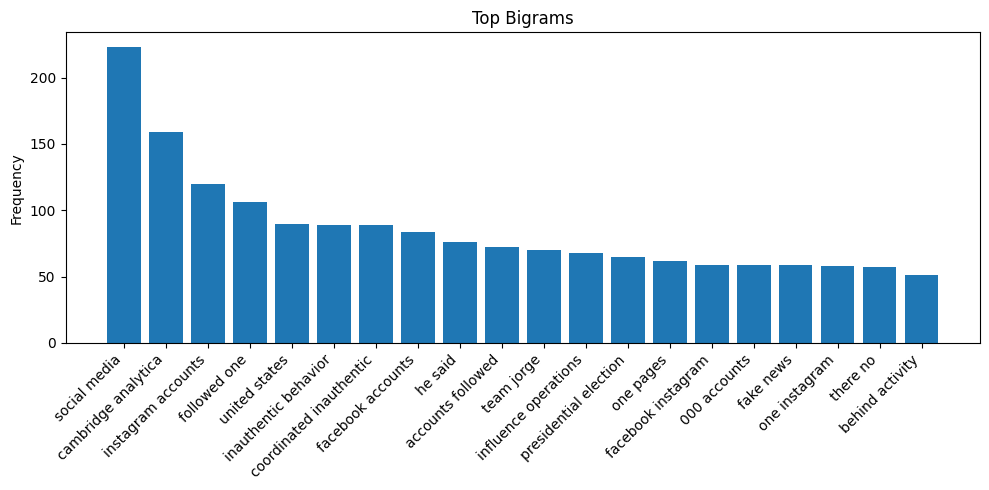

In [ ]:
#Graph
plt.figure(figsize=(10,5))
plt.bar(bi_df["bigram"], bi_df["freq"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Top Bigrams")
plt.tight_layout()
plt.show()

In [ ]:
#Top Trigrams
vectorizer3 = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(3,3),
    max_features=20
)

X3 = vectorizer3.fit_transform(text_df["text"])

tri_counts = np.array(X3.sum(axis=0)).flatten()
tri_terms = vectorizer3.get_feature_names_out()

tri_df = pd.DataFrame({
    "trigram": tri_terms,
    "freq": tri_counts
}).sort_values("freq", ascending=False)

tri_df

,trigram,freq
5,coordinated inauthentic behavior,88
4,accounts followed one,57
11,one instagram accounts,57
7,followed one pages,54
0,000 accounts followed,52
6,followed one instagram,49
16,pt reflect latest,49
14,people followed one,49
3,50pm pt reflect,44
2,21 2020 50pm,44


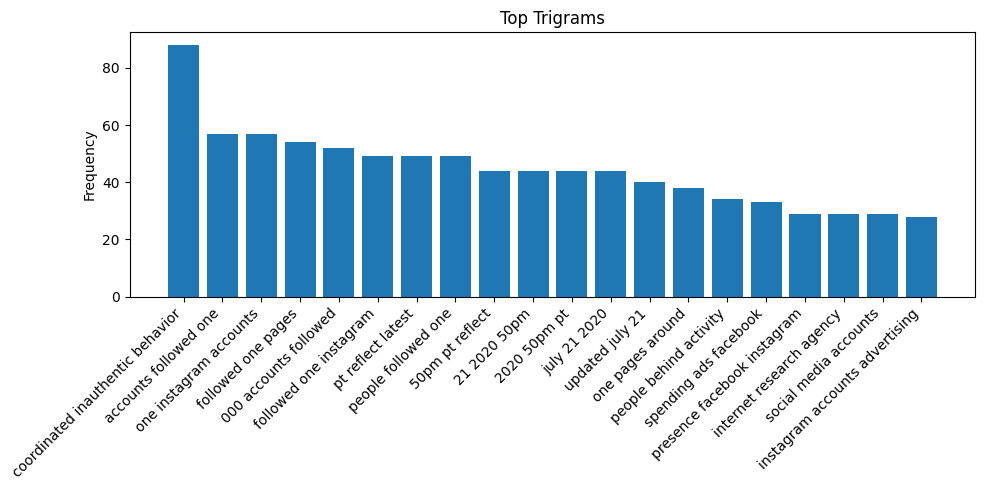

In [ ]:
#Graph
plt.figure(figsize=(10,5))
plt.bar(tri_df["trigram"], tri_df["freq"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Top Trigrams")
plt.tight_layout()
plt.show()

In [ ]:
#TF-IDF Keywords
tfidf = TfidfVectorizer(
    stop_words=list(STOPWORDS),
    max_features=20
)

X_tfidf = tfidf.fit_transform(text_df["text"])
scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
terms = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame({"term": terms, "score": scores}).sort_values("score", ascending=False)
tfidf_df

,term,score
0,accounts,0.208613
15,russian,0.190586
4,election,0.160989
16,said,0.149380
8,media,0.144450
6,facebook,0.144053
7,he,0.130834
17,social,0.123521
1,campaign,0.120420
13,political,0.119455


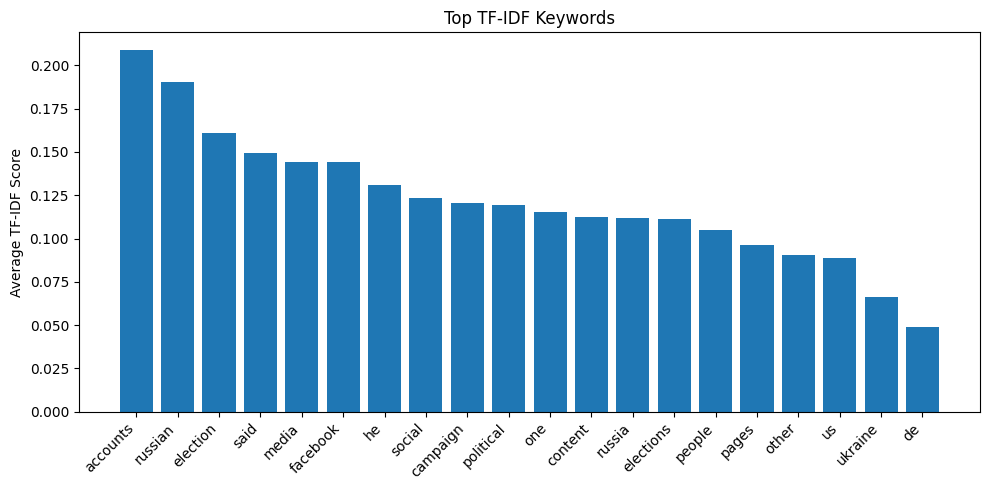

In [ ]:
#Graph
plt.figure(figsize=(10,5))
plt.bar(tfidf_df["term"], tfidf_df["score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average TF-IDF Score")
plt.title("Top TF-IDF Keywords")
plt.tight_layout()
plt.show()

In [ ]:
#Sentiment Analysis
# Compute sentiment for each article
text_df["sentiment"] = text_df["text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
text_df[["file_name", "sentiment"]].head()

,file_name,sentiment
0,29_Source_2.md,0.093950
1,68_Source_4.md,0.000000
2,69_Source_1.md,0.000000
3,9_Source_8.md,0.046558
4,19_Source_3.md,-0.012655


In [ ]:
text_df["sentiment"].describe()

,sentiment
count,136.000000
mean,0.037668
std,0.064937
min,-0.244444
25%,0.007321
50%,0.035943
75%,0.063533
max,0.433333


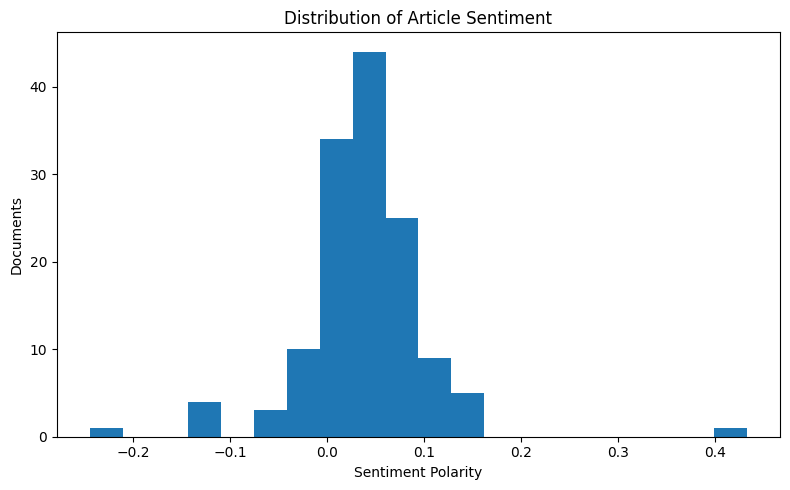

In [ ]:
#Sentiment Histogram
plt.figure(figsize=(8,5))
plt.hist(text_df["sentiment"], bins=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Documents")
plt.title("Distribution of Article Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
#Sentiment Categories
def label_sentiment(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

text_df["sentiment_label"] = text_df["sentiment"].apply(label_sentiment)
sent_counts = text_df["sentiment_label"].value_counts()
sent_counts

,count
sentiment_label,
Neutral,117
Positive,14
Negative,5


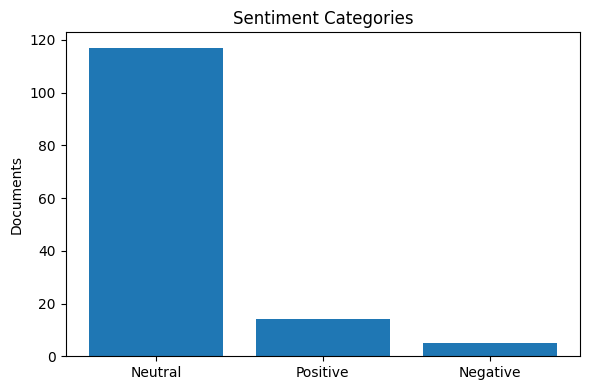

In [ ]:
#Category Chart
plt.figure(figsize=(6,4))
plt.bar(sent_counts.index, sent_counts.values)
plt.ylabel("Documents")
plt.title("Sentiment Categories")
plt.tight_layout()
plt.show()

Classification Report:

                      precision    recall  f1-score   support

    Adversary Action       0.98      1.00      0.99       456
     General Context       0.97      0.97      0.97       313
        Non-relevant       0.97      0.98      0.97       118
Speculation/Analysis       0.99      0.92      0.95       152

            accuracy                           0.98      1039
           macro avg       0.98      0.97      0.97      1039
        weighted avg       0.98      0.98      0.98      1039



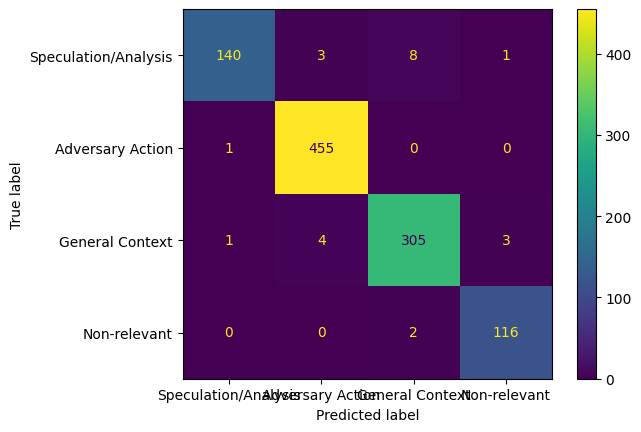

In [ ]:
#Task 3
df2 = pd.read_csv("adversary_actions_dataset (1).csv")
X = df2['statement'] + " " + df2['justification'] #Input features
y = df2['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Split dataset, stratify is used to keep class proportions balanced on train and test
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,3))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=df2['label'].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df2['label'].unique())
disp.plot()

                              precision    recall  f1-score   support

      Applied Countermeasure       0.89      0.94      0.91        33
Countermeasure Effectiveness       0.96      0.86      0.91        28
  Non-Countermeasure Related       0.98      1.00      0.99        61
  Recommended Countermeasure       0.93      0.93      0.93        56

                    accuracy                           0.94       178
                   macro avg       0.94      0.93      0.93       178
                weighted avg       0.94      0.94      0.94       178



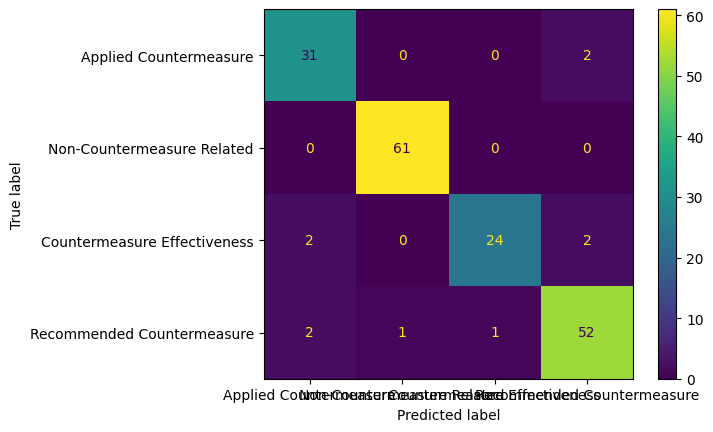

In [ ]:
df3 = pd.read_csv("countermeasures_dataset.csv")
df3['justification'] = df3['justification'].fillna('') #Some observations had missing justifications so they're replaced with empty string
X = df3['statement'] + " " + df3['justification']
y = df3['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,3))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=df3['label'].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df3['label'].unique())
disp.plot()

In [ ]:
#Define our paths
DATA_PATH = "/content/adversary_actions_dataset (1).csv"
MODEL_PATH = "/content/drive/MyDrive/NLP/roberta_model"

df = pd.read_csv(DATA_PATH, engine="python", on_bad_lines="skip")
df["justification"] = df["justification"].fillna("")
df["text"] = df["statement"] + " " + df["justification"]

#Replace labels with numbers (0,1,2..)
labels_unique = sorted(df["label"].unique())
label2id = {label: i for i, label in enumerate(labels_unique)}
id2label = {i: label for label, i in label2id.items()}
df["labels"] = df["label"].map(label2id) #Apply mapping

_, test_df = train_test_split(df[["text", "labels", "label"]], test_size=0.2, random_state=42, stratify=df["label"]) #Keep only the test portion as this is for evaluation, not training

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH) #Load tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH) #Load our saved distilroberta model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Use gpu if available, otherwise use cpu
model.to(device)
model.eval()

def predict_texts(texts, batch_size=16): #Process 16 texts at once instead of one by one, faster/memory efficient
    preds_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt") #tokenize text
        inputs = {k: v.to(device) for k, v in inputs.items()} #move inputs to device (gpu/cpu)

        with torch.no_grad():
            outputs = model(**inputs) #Produce raw scores per class

        preds = torch.argmax(outputs.logits, dim=1) #Select best class
        preds_all.extend(preds.cpu().numpy()) #Store predictions

    return np.array(preds_all)

#Predict test set
y_true = test_df["labels"].values
y_pred = predict_texts(test_df["text"].tolist())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(len(id2label))]))

Accuracy: 0.9884504331087585
Weighted F1: 0.9884153097835671

Classification Report:

                      precision    recall  f1-score   support

    Adversary Action       1.00      1.00      1.00       456
     General Context       0.98      0.99      0.98       313
        Non-relevant       0.99      0.97      0.98       118
Speculation/Analysis       0.99      0.96      0.97       152

            accuracy                           0.99      1039
           macro avg       0.99      0.98      0.98      1039
        weighted avg       0.99      0.99      0.99      1039



In [ ]:
DATA_PATH = "/content/countermeasures_dataset.csv"
MODEL_PATH = "/content/drive/MyDrive/NLP/countermeasures_roberta_model"

df = pd.read_csv(DATA_PATH, engine="python", on_bad_lines="skip")
df["justification"] = df["justification"].fillna("")
df["text"] = df["statement"] + " " + df["justification"]

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Use label mapping stored inside the saved model
label2id = model.config.label2id
id2label = model.config.id2label

df["labels"] = df["label"].map(label2id)

_, test_df = train_test_split(
    df[["text", "labels", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict_texts(texts, batch_size=16):
    preds_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        preds = torch.argmax(outputs.logits, dim=1)
        preds_all.extend(preds.cpu().numpy())

    return np.array(preds_all)

y_true = test_df["labels"].values
y_pred = predict_texts(test_df["text"].tolist())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=[id2label[str(i)] if isinstance(list(id2label.keys())[0], str) else id2label[i] for i in range(len(id2label))]
))

Accuracy: 0.9662921348314607
Weighted F1: 0.965713526168524

Classification Report:

                              precision    recall  f1-score   support

      Applied Countermeasure       0.94      0.97      0.96        33
Countermeasure Effectiveness       0.96      0.86      0.91        28
  Non-Countermeasure Related       0.97      1.00      0.98        61
  Recommended Countermeasure       0.98      0.98      0.98        56

                    accuracy                           0.97       178
                   macro avg       0.96      0.95      0.96       178
                weighted avg       0.97      0.97      0.97       178

